# Analisi Qualità Dati RTP x Supporto GO-LIVE (Tassonomie, Date Scadenza)

Questo notebook esegue una serie di passaggi per identificare la qualità di alcuni campi delle posizioni debitorie GPD.

**Versione ottimizzata** — eliminati i colli di bottiglia principali:
- Query SQL: filtri pushdown, colonne ridotte al minimo
- Codice duplicato: tassonomia caricata una sola volta
- `iterrows()` eliminato → operazioni vettoriali Pandas (~100x più veloce)

# Perimetro Dati in analisi
1) Posizioni Debitorie su GPD e ACA (no paCreatePosition)
2) Posizioni Debitore "VALID"
3) Periodo temporale 02/03/2026 → 10/04/2026

In [1]:
import cml.data_v1 as cmldata

CONNECTION_NAME = "dl-analysis-impala-vw"
conn = cmldata.get_connection(CONNECTION_NAME)

In [2]:
# ==========================================================================
# QUERY OTTIMIZZATA
# ==========================================================================
# Miglioramenti rispetto all'originale:
#   1. SELECT solo le colonne effettivamente usate nel notebook
#   2. Filtro inserted_date spostato nella clausola ON dei JOIN dove possibile
#   3. Filtro IUPD con NOT LIKE spostato in posizione esplicita
#   4. Se Impala lo supporta, considera COMPUTE STATS sulle tabelle coinvolte

QUERY = """
SELECT
    t.after.category       AS category,
    po.after.description   AS description,
    pp.after.id            AS id,
    pp.after.iupd          AS iupd,
    po.after.due_date      AS due_date,
    pp.after.company_name  AS company_name
FROM pagopa.silver_gpd_payment_position pp
INNER JOIN pagopa.silver_gpd_payment_option po
    ON pp.after.id = po.after.payment_position_id
INNER JOIN pagopa.silver_gpd_transfer t
    ON t.after.payment_option_id = po.after.id
WHERE
    pp.after.inserted_date IS NOT NULL
    AND pp.after.inserted_date
        BETWEEN unix_timestamp('2026-03-02 00:00:01') * 1000000
            AND unix_timestamp('2026-04-10 00:00:00') * 1000000
    AND pp.after.status = 'VALID'
    AND pp.after.iupd NOT LIKE 'ACA\_%'
    AND pp.after.service_type IN ('GPD', 'ACA')
"""

dataframe = conn.get_pandas_dataframe(QUERY)
conn.close()

print(f"Record caricati: {len(dataframe):,}")
print(f"Colonne: {list(dataframe.columns)}")
print(f"Memoria: {dataframe.memory_usage(deep=True).sum() / 1e6:.1f} MB")


Record caricati: 15,358,863
Colonne: ['category', 'description', 'id', 'iupd', 'due_date', 'company_name']
Memoria: 5665.2 MB


In [3]:
import pandas as pd
import re
import requests
import io
import csv

# ==========================================================================
# CARICAMENTO TASSONOMIA (eseguito una sola volta, poi riusato)
# ==========================================================================

url_taxonomy = "https://api.platform.pagopa.it/taxonomy/service/v1/taxonomy?extension=csv"
col_ref = 'dati_specifici_di_incasso'

try:
    response = requests.get(url_taxonomy, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
    response.raise_for_status()

    f = io.StringIO(response.text)
    reader = csv.reader(f, delimiter=';')
    header = [h.replace('"', '').strip() for h in next(reader)]
    col_idx = header.index(col_ref)

    valid_codes_list = []
    scarti_csv = []

    for i, row in enumerate(reader, start=2):
        if len(row) > col_idx:
            raw_code = row[col_idx].replace('"', '').strip()
            if re.match(r'^[6-9]/', raw_code):
                valid_codes_list.append(raw_code)
            else:
                scarti_csv.append((i, raw_code, 'Formato non valido'))
        else:
            scarti_csv.append((i, 'N/D', 'Colonna mancante'))

    valid_codes_set = set(valid_codes_list)

    print(f"--- TASSONOMIA ---")
    print(f"Record processati:   {len(valid_codes_list) + len(scarti_csv)}")
    print(f"Codici univoci:      {len(valid_codes_set)}")
    print(f"Righe scartate:      {len(scarti_csv)}")

    if scarti_csv:
        print(f"\nPrime 10 righe non valide:")
        for riga, val, motivo in scarti_csv[:10]:
            print(f"  Riga {riga}: '{val}' — {motivo}")

except Exception as e:
    print(f"❌ Errore caricamento tassonomia: {e}")
    valid_codes_set = set()


--- TASSONOMIA ---
Record processati:   3036
Codici univoci:      3028
Righe scartate:      8

Prime 10 righe non valide:
  Riga 1514: '47' — Formato non valido
  Riga 1542: '47' — Formato non valido
  Riga 1570: '47' — Formato non valido
  Riga 1598: '47' — Formato non valido
  Riga 2466: '47' — Formato non valido
  Riga 2609: '47' — Formato non valido
  Riga 2752: '47' — Formato non valido
  Riga 2895: '47' — Formato non valido


In [4]:
# ==========================================================================
# VALIDAZIONE TASSONOMICA (consolidata — era ripetuta in 3 celle)
# ==========================================================================
# Tutte le operazioni sono VETTORIALI su Pandas (nessun loop row-by-row)

taxonomic_regex = r'^(9|6|7|8)\/\d{7}(IM|TS|SP|SA|AP)\/?$'
secondary_regex = r'^\d{7}(IM|TS|SP|SA|AP)$'

assert 'category' in dataframe.columns, "Colonna 'category' non trovata!"

# Normalizzazione (una sola volta)
dataframe['category_clean'] = (
    dataframe['category']
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.strip()
)

# Validazioni vettoriali
dataframe['is_syntax_correct']       = dataframe['category_clean'].str.match(taxonomic_regex, na=False)
dataframe['is_secondary_syntax']     = dataframe['category_clean'].str.match(secondary_regex, na=False)
dataframe['is_semantically_correct'] = dataframe['category_clean'].isin(valid_codes_set)
dataframe['is_specific_prefix']      = (
    dataframe['is_semantically_correct'] &
    dataframe['category_clean'].str.match(r'^[6-8]/', na=False)
)

# --- REPORT ---
total = len(dataframe)
syntax_ok  = dataframe['is_syntax_correct'].sum()
syntax_ko  = total - syntax_ok
semantic_ok = dataframe['is_semantically_correct'].sum()
prefix_ok   = dataframe['is_specific_prefix'].sum()

syntax_ko_df = dataframe[~dataframe['is_syntax_correct']]
secondary_ok = syntax_ko_df['is_secondary_syntax'].sum()

print("=" * 95)
print("📊 REPORT GENERALE ANALISI CODICI TASSONOMICI")
print("=" * 95)
print(f"Totale record analizzati:      {total:,}")
print(f"1) Rispettano la sintassi:     {syntax_ok:,} ✅")
print(f"2) NON rispettano la sintassi: {syntax_ko:,} ❌")
print(f"   2.1) Recuperabili (prefisso mancante): {secondary_ok:,}")
if syntax_ko > 0:
    print(f"   % recuperabili: {secondary_ok / syntax_ko:.2%}")
print(f"3) Semanticamente corretti:    {semantic_ok:,} 🏛️")
print(f"4) Prefissi Specifici (6/7/8): {prefix_ok:,} 🏷️")
print("-" * 95)

# --- ESEMPI ---
print("\nESEMPI REALI:")
for label, mask in [
    ("✅ Sintassi OK",       dataframe['is_syntax_correct']),
    ("❌ Sintassi Errata",   ~dataframe['is_syntax_correct']),
    ("🔄 Sintassi Alt.",     dataframe['is_secondary_syntax']),
    ("🏛️ Semantica OK",     dataframe['is_semantically_correct']),
    ("🏷️ Prefisso 6/7/8",  dataframe['is_specific_prefix']),
]:
    sub = dataframe[mask]
    if not sub.empty:
        r = sub.iloc[0]
        print(f"{label:25} -> {r['category']:15} | ID: {r.get('id','N/D'):15} | IUPD: {r.get('iupd','N/D')}")
    else:
        print(f"{label:25} -> Nessun record")


📊 REPORT GENERALE ANALISI CODICI TASSONOMICI
Totale record analizzati:      15,358,863
1) Rispettano la sintassi:     10,966,438 ✅
2) NON rispettano la sintassi: 4,392,425 ❌
   2.1) Recuperabili (prefisso mancante): 2,596,334
   % recuperabili: 59.11%
3) Semanticamente corretti:    10,338,762 🏛️
4) Prefissi Specifici (6/7/8): 6,498,286 🏷️
-----------------------------------------------------------------------------------------------

ESEMPI REALI:
✅ Sintassi OK             -> 6/0102106SA/    | ID:       316409353 | IUPD: EASYPAI_ACIC6_00145920351_06790000021068315
❌ Sintassi Errata         -> 0501100TS       | ID:       318209848 | IUPD: 1530208239-afab45c5a7cc-ecd6fdaa5a4a
🔄 Sintassi Alt.           -> 0501100TS       | ID:       318209848 | IUPD: 1530208239-afab45c5a7cc-ecd6fdaa5a4a
🏛️ Semantica OK           -> 6/0102106SA/    | ID:       316409353 | IUPD: EASYPAI_ACIC6_00145920351_06790000021068315
🏷️ Prefisso 6/7/8         -> 6/0102106SA/    | ID:       316409353 | IUPD: EASYPAI_ACI

In [5]:
# ==========================================================================
# STATISTICHE PER COMPANY (Top 50) + Dettaglio prefissi 6/7/8
# ==========================================================================

if 'company_name' in dataframe.columns:

    # Aggregazione vettoriale
    stats = dataframe.groupby('company_name', sort=False).agg(
        Sintassi_OK   = ('is_syntax_correct', 'sum'),
        Sintassi_Alt  = ('is_secondary_syntax', 'sum'),
        Semantica_OK  = ('is_semantically_correct', 'sum'),
        Prefissi_678  = ('is_specific_prefix', 'sum'),
        Totale        = ('category', 'count')
    )
    stats['Sintassi_KO'] = stats['Totale'] - stats['Sintassi_OK']
    stats['%_Prefisso_678'] = (stats['Prefissi_678'] / stats['Semantica_OK']).fillna(0) * 100

    top_50 = stats.sort_values('Totale', ascending=False).head(50)

    print("=" * 110)
    print("🏢 TOP 50 COMPANY PER VOLUME")
    print("=" * 110)
    display(top_50[['Sintassi_OK','Sintassi_KO','Sintassi_Alt','Semantica_OK','Prefissi_678','%_Prefisso_678','Totale']])

    # --- Dettaglio codici 6/7/8 per company ---
    df_678 = dataframe[dataframe['is_specific_prefix']].copy()

    if not df_678.empty:
        print("\n" + "=" * 95)
        print("🏷️ DETTAGLIO CODICI PREFISSO 6/7/8 PER AZIENDA")
        print("=" * 95)

        # Aggregazione vettoriale (nessun loop row-by-row)
        detail = (
            df_678.groupby(['company_name', 'category_clean'])
            .size()
            .reset_index(name='Occorrenze')
            .sort_values(['company_name', 'Occorrenze'], ascending=[True, False])
        )

        for company, grp in detail.groupby('company_name', sort=False):
            tot = grp['Occorrenze'].sum()
            uni = len(grp)
            print(f"\n🏢 {company} [{tot} record | {uni} univoci]")
            for _, r in grp.iterrows():
                print(f"   - {r['category_clean']:<25} ({r['Occorrenze']} occ.)")
            print("-" * 50)
    else:
        print("\n⚠️ Nessun record con prefisso 6/7/8.")

else:
    print("⚠️ Colonna 'company_name' non trovata.")


🏢 TOP 50 COMPANY PER VOLUME


,Sintassi_OK,Sintassi_KO,Sintassi_Alt,Semantica_OK,Prefissi_678,%_Prefisso_678,Totale
company_name,,,,,,,
Sorit S.p.A.,1820342,0,0,1820342,1820342,100.000000,1820342
Consorzio della Bonifica Renana,498183,0,0,498183,498183,100.000000,498183
COMUNE DI FIRENZE,473939,1382,0,473939,136967,28.899711,475321
ACQUEDOTTO PUGLIESE S.P.A.,0,455969,0,0,0,0.000000,455969
Consorzio di Bonifica Pianura di Ferrara,416473,0,0,416473,416473,100.000000,416473
Comune di Bologna,222688,1,1,222169,0,0.000000,222689
Citta Metropolitana di Milano,218440,0,0,218440,193143,88.419246,218440
Ge.Fi.L. Spa - Gestione Fiscalita' Locale,213493,0,0,213493,213493,100.000000,213493
Fintel Engineering S.r.l.,187080,0,0,187080,187080,100.000000,187080



🏷️ DETTAGLIO CODICI PREFISSO 6/7/8 PER AZIENDA

🏢 A.AM.P.S. Azienda Ambientale di Pubblico Servizio S.p.A. [2 record | 1 univoci]
   - 6/0115107AP/              (2 occ.)
--------------------------------------------------

🏢 A.O.U. San Luigi Gonzaga [14 record | 1 univoci]
   - 6/0501112TS/              (14 occ.)
--------------------------------------------------

🏢 ACCADEMIA ALBERTINA DI BELLE ARTI DI TORINO [28 record | 2 univoci]
   - 6/0601100TS/              (27 occ.)
   - 6/0601102TS/              (1 occ.)
--------------------------------------------------

🏢 ACCADEMIA DELLE BELLE ARTI DI MACERATA [24 record | 1 univoci]
   - 6/0601102TS/              (24 occ.)
--------------------------------------------------

🏢 ACER MODENA [4418 record | 1 univoci]
   - 6/0901100AP/              (4418 occ.)
--------------------------------------------------

🏢 ACS Nova Milanese [165 record | 1 univoci]
   - 6/0107101TS/              (165 occ.)
--------------------------------------------------

## Analisi lunghezza causali

> 1 e <= 30 car.: 3912319 record (25.47%)
> 30 e <= 50 car.: 5454901 record (35.52%)
> 50 e <= 70 car.: 1969185 record (12.82%)
> 70 e <= 100 car.: 2709375 record (17.64%)
> 100 e <= 140 car.: 43366 record (0.28%)
> 140 car.: 0 record (0.00%)


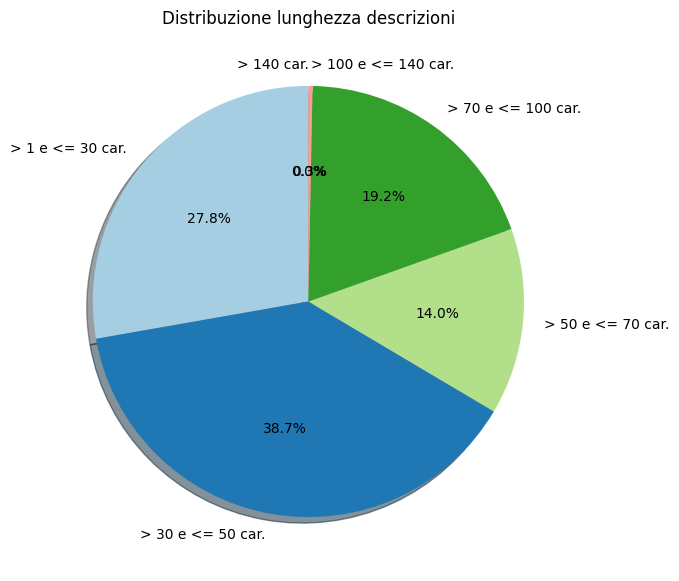

In [6]:
import matplotlib.pyplot as plt

def analyze_description_length(df):
    bins = [(1, 30), (31, 50), (51, 70), (71, 100), (101, 140), (141, float('inf'))]
    labels = [
        "> 1 e <= 30 car.", "> 30 e <= 50 car.", "> 50 e <= 70 car.",
        "> 70 e <= 100 car.", "> 100 e <= 140 car.", "> 140 car."
    ]

    total = len(df)
    if total == 0:
        print("Nessun record.")
        return

    lengths = df['description'].str.len()
    counts = [((lengths > lo) & (lengths <= hi)).sum() for lo, hi in bins]

    for lbl, cnt in zip(labels, counts):
        print(f"{lbl}: {cnt} record ({cnt/total*100:.2f}%)")

    plt.figure(figsize=(7, 7))
    plt.pie(counts, labels=labels, autopct='%1.1f%%',
            colors=plt.cm.Paired.colors, shadow=True, startangle=90)
    plt.title('Distribuzione lunghezza descrizioni')
    plt.show()

analyze_description_length(dataframe)


## Analisi Date Scadenza

📅 PANORAMICA VALORI due_date (PRIMA del filtraggio)
Record con due_date non null: 15,358,863
Anno min: 2026  |  Anno max: 9999

Distribuzione per anno (185 anni distinti):

⚠️  ANNI FUORI RANGE (2000-2100): 1,199,768 record
   Anno 2101: 8 record
   Anno 2102: 8 record
   Anno 2103: 9 record
   Anno 2104: 8 record
   Anno 2105: 8 record
   Anno 2106: 8 record
   Anno 2107: 8 record
   Anno 2108: 7 record
   Anno 2109: 7 record
   Anno 2110: 8 record
   Anno 2111: 7 record
   Anno 2112: 7 record
   Anno 2113: 8 record
   Anno 2114: 7 record
   Anno 2115: 8 record
   Anno 2116: 7 record
   Anno 2117: 7 record
   Anno 2118: 8 record
   Anno 2119: 8 record
   Anno 2120: 9 record
   Anno 2121: 8 record
   Anno 2122: 7 record
   Anno 2123: 7 record
   Anno 2124: 6 record
   Anno 2125: 8 record
   Anno 2126: 770 record
   Anno 2127: 8 record
   Anno 2128: 8 record
   Anno 2129: 8 record
   Anno 2130: 7 record
   Anno 2131: 7 record
   Anno 2132: 8 record
   Anno 2133: 8 record
   Anno 2134: 8

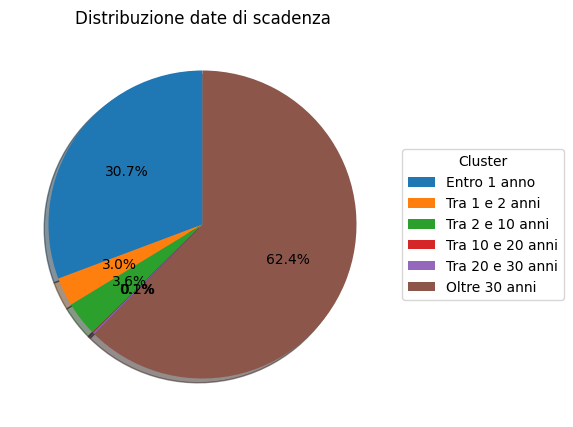


--- TOP 50 COMPANY PER CLUSTER ---

🔎 CLUSTER: Entro 1 anno
  1. COMUNE DI FIRENZE: 335,318
  2. Octopus Energy Italia: 155,622
  3. Consorzio di Bonifica della Media Pianura Bergamasca: 152,836
  4. Comune di Ancona: 117,371
  5. Comune di Gioia Tauro: 105,255
  6. Comune di Monreale: 102,133
  7. Comune di Arzano: 97,029
  8. Veneziana Energia Risorse Idriche Territorio Ambiente Servizi S.P.A.: 92,595
  9. Provincia di Brescia: 64,478
  10. Comune di Santa Maria a Monte: 64,208
  11. Comune di Porto Torres: 63,214
  12. Consorzio Bonifica Territori del Mincio: 60,074
  13. Ministero dell'Ambiente e della Sicurezza Energetica: 59,396
  14. Autostrada Pedemontana Lombarda Spa: 57,169
  15. Comune di Capaci: 50,231
  16. CAFC SPA: 40,303
  17. ESA S.P.A. SOCIETA' BENEFIT: 38,381
  18. Comune di Verona: 35,179
  19. ASL Napoli 1 Centro: 35,124
  20. ASL Salerno: 35,117
  21. Alperia Smart Services Srl: 35,099
  22. Comune di Siracusa: 34,574
  23. Comune di Ragusa: 33,226
  24. Comune d

In [8]:
import numpy as np
from collections import Counter

# ==========================================================================
# ANALISI DATE SCADENZA — VERSIONE VETTORIALE
# ==========================================================================
# L'originale usava iterrows() con tqdm: O(n) Python puro, lentissimo.
# Questa versione usa np.searchsorted → ~100x più veloce su dataset grandi.

def analyze_due_dates_vectorized(df):
    total = len(df)
    if total == 0 or 'due_date' not in df.columns:
        print("Nessun record o colonna 'due_date' mancante.")
        return

    df_f = df.dropna(subset=['due_date']).copy()

    # =====================================================
    # STEP 0: Analisi esplorativa PRIMA del clamp
    # Converte in anni tramite aritmetica pura (no datetime)
    # così vediamo anche anno 9999, date negative, ecc.
    # =====================================================
    ts_seconds = df_f['due_date'] / 1_000_000
    EPOCH = pd.Timestamp('1970-01-01', tz='UTC')
    # Anno approssimativo: epoch + secondi → anno
    df_f['_approx_year'] = (1970 + ts_seconds / (365.25 * 86400)).astype(int)

    print('=' * 95)
    print('📅 PANORAMICA VALORI due_date (PRIMA del filtraggio)')
    print('=' * 95)
    year_counts = df_f['_approx_year'].value_counts().sort_index()
    print(f'Record con due_date non null: {len(df_f):,}')
    print(f'Anno min: {df_f["_approx_year"].min()}  |  Anno max: {df_f["_approx_year"].max()}')
    print(f'\nDistribuzione per anno ({len(year_counts)} anni distinti):')
    # Mostra tutti gli anni con >0 record, raggruppando quelli "normali" vs outlier
    YEAR_LO, YEAR_HI = 2000, 2100
    outliers = year_counts[(year_counts.index < YEAR_LO) | (year_counts.index > YEAR_HI)]
    normals  = year_counts[(year_counts.index >= YEAR_LO) & (year_counts.index <= YEAR_HI)]
    if not outliers.empty:
        print(f'\n⚠️  ANNI FUORI RANGE ({YEAR_LO}-{YEAR_HI}): {outliers.sum():,} record')
        for yr, cnt in outliers.items():
            print(f'   Anno {yr}: {cnt:,} record')
        # Dettaglio company per gli outlier
        if 'company_name' in df_f.columns:
            df_outlier = df_f[(df_f['_approx_year'] < YEAR_LO) | (df_f['_approx_year'] > YEAR_HI)]
            print(f'\n   Top 20 company con date fuori range:')
            for comp, cnt in df_outlier['company_name'].value_counts().head(20).items():
                print(f'     {comp}: {cnt:,}')
    if not normals.empty:
        print(f'\n📊 Anni nel range {YEAR_LO}-{YEAR_HI}: {normals.sum():,} record')
        for yr, cnt in normals.items():
            print(f'   {yr}: {cnt:,}')

    # =====================================================
    # STEP 1: Conversione datetime (clamp per Pandas)
    # =====================================================
    MIN_TS, MAX_TS = -9.2e9, 9.2e9  # range datetime64[ns]
    ts_clamped = ts_seconds.where(ts_seconds.between(MIN_TS, MAX_TS))
    df_f['date_converted'] = pd.to_datetime(ts_clamped, unit='s', utc=True, errors='coerce')

    n_clamped = df_f['date_converted'].isna().sum()
    if n_clamped > 0:
        print(f'\n⚠️ {n_clamped:,} record oltre il range Pandas (~1677-2262) — esclusi dal clustering ma contati sopra')
    df_f = df_f.dropna(subset=['date_converted'])

    today = pd.Timestamp.now(tz='UTC')
    df_f['delta_years'] = (df_f['date_converted'] - today).dt.total_seconds() / (365 * 24 * 3600)

    # Cluster con np.searchsorted (vettoriale, nessun loop)
    boundaries = [0, 1, 2, 10, 20, 30, np.inf]
    cluster_names = [
        "Entro 1 anno", "Tra 1 e 2 anni", "Tra 2 e 10 anni",
        "Tra 10 e 20 anni", "Tra 20 e 30 anni", "Oltre 30 anni"
    ]

    # np.searchsorted assegna ogni valore al bin corretto
    df_f['cluster_idx'] = np.searchsorted(boundaries[1:], df_f['delta_years'].values, side='right')
    df_f['cluster_idx'] = df_f['cluster_idx'].clip(0, len(cluster_names) - 1)
    df_f['cluster'] = df_f['cluster_idx'].map(dict(enumerate(cluster_names)))

    # --- 1. Conteggio cluster ---
    print("\n--- ANALISI CLUSTER TEMPORALI ---")
    cluster_counts = df_f['cluster'].value_counts()
    for name in cluster_names:
        cnt = cluster_counts.get(name, 0)
        print(f"{name}: {cnt:,} record ({cnt/total*100:.2f}%)")

    # --- 2. Grafico ---
    counts = [cluster_counts.get(n, 0) for n in cluster_names]
    plt.figure(figsize=(8, 5))
    plt.pie(counts, autopct='%1.1f%%', shadow=True, startangle=90)
    plt.legend(cluster_names, title="Cluster", loc="center left", bbox_to_anchor=(1, 0.5))
    plt.title("Distribuzione date di scadenza")
    plt.subplots_adjust(right=0.7)
    plt.show()

    # --- 3. Top 50 company per cluster ---
    print("\n--- TOP 50 COMPANY PER CLUSTER ---")
    if 'company_name' in df_f.columns:
        for name in cluster_names:
            sub = df_f[df_f['cluster'] == name]
            print(f"\n🔎 CLUSTER: {name}")
            if not sub.empty:
                top = sub['company_name'].value_counts().head(50)
                for i, (comp, cnt) in enumerate(top.items(), 1):
                    print(f"  {i}. {comp}: {cnt:,}")
            else:
                print("  Nessun record.")

analyze_due_dates_vectorized(dataframe)

